In [1]:
!gcloud auth application-default login

Your browser has been opened to visit:

    https://accounts.google.com/o/oauth2/auth?response_type=code&client_id=764086051850-6qr4p6gpi6hn506pt8ejuq83di341hur.apps.googleusercontent.com&redirect_uri=http%3A%2F%2Flocalhost%3A8085%2F&scope=openid+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fuserinfo.email+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fcloud-platform+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fsqlservice.login&state=cEpFBaHwStAetqroTCQHgY2TmTBpl3&access_type=offline&code_challenge=Kqy7A5py7FJF5FEqCdGRmYqO7z9e45msuBxC6b0ETVY&code_challenge_method=S256


Credentials saved to file: [/Users/yt4/.config/gcloud/application_default_credentials.json]

These credentials will be used by any library that requests Application Default Credentials (ADC).

Quota project "open-targets-genetics-dev" was added to ADC which can be used by Google client libraries for billing and quota. Note that some services may still bill the project owning the resource.


In [ ]:
import os

import hail as hl
import numpy as np
import pyspark.sql.functions as f
from pyspark.sql import DataFrame

from gentropy.common.session import Session
from gentropy.dataset.study_index import StudyIndex
from gentropy.dataset.summary_statistics import SummaryStatistics
from gentropy.dataset.study_locus import StudyLocus
from gentropy.susie_finemapper import SusieFineMapperStep
from gentropy.method.drug_enrichment_from_evid import chemblDrugEnrichment

"""Common utilities for the project."""

import os
from pathlib import Path
from gentropy.common.session import Session
import logging


def get_gcs_credentials() -> str:
    """Get the credentials for google cloud storage."""
    app_default_credentials = os.path.join(
        os.getenv("HOME", "."), ".config/gcloud/application_default_credentials.json"
    )

    service_account_credentials = os.path.join(
        os.getenv("HOME", "."), ".config/gcloud/service_account_credentials.json"
    )

    if Path(app_default_credentials).exists():
        return app_default_credentials
    else:
        raise FileNotFoundError("No GCS credentials found.")


def get_gcs_hadoop_connector_jar() -> str:
    """Get the google cloud storage hadoop connector for spark.

    This function will return the url to download the hadoop jar.
    """

    return (
        "https://storage.googleapis.com/hadoop-lib/gcs/gcs-connector-hadoop3-latest.jar"
    )


def gcs_conf(
    credentials_path=None, project="open-targets-genetics-dev"
) -> dict[str, str]:
    """Get the spark configuration with hadoop connector for google cloud storage."""
    credentials_path = credentials_path or get_gcs_credentials()
    return {
        "spark.driver.memory": "12g",
        "spark.kryoserializer.buffer.max": "500m",
        "spark.driver.maxResultSize": "2g",
        "spark.hadoop.fs.gs.impl": "com.google.cloud.hadoop.fs.gcs.GoogleHadoopFileSystem",
        "spark.jars": get_gcs_hadoop_connector_jar(),
        "spark.hadoop.google.cloud.auth.service.account.enable": "true",
        "spark.hadoop.fs.gs.project.id": project,
        "spark.hadoop.google.cloud.auth.service.account.json.keyfile": credentials_path,
        "spark.hadoop.fs.gs.requester.pays.mode": "AUTO",
    }


class GentropySession(Session):
    def __init__(self, *args, **kwargs):
        if "extended_spark_conf" in kwargs:
            kwargs["extended_spark_conf"].update(gcs_conf())
        else:
            kwargs["extended_spark_conf"] = gcs_conf()
        super().__init__(*args, **kwargs)

    @property
    def conf(self):
        logging.warning(
            "To change the config restart the session and use the `extended_spark_conf` parameter."
        )
        return self.spark.sparkContext.getConf().getAll()


session = GentropySession()


Loading BokehJS ...

/Users/yt4/Projects/gentropy/.venv/lib/python3.11/site-packages/pyspark/sql/pandas/functions.py:407: UserWarning:

In Python 3.6+ and Spark 3.0+, it is preferred to specify type hints for pandas UDF instead of specifying pandas UDF type which will be deprecated in the future releases. See SPARK-28264 for more details.

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/09/18 11:48:28 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


----------------------------------------
Exception occurred during processing of request from ('127.0.0.1', 64686)
Traceback (most recent call last):
  File "/Users/yt4/.local/share/uv/python/cpython-3.11.11-macos-aarch64-none/lib/python3.11/socketserver.py", line 317, in _handle_request_noblock
    self.process_request(request, client_address)
  File "/Users/yt4/.local/share/uv/python/cpython-3.11.11-macos-aarch64-none/lib/python3.11/socketserver.py", line 348, in process_request
    self.finish_request(request, client_address)
  File "/Users/yt4/.local/share/uv/python/cpython-3.11.11-macos-aarch64-none/lib/python3.11/socketserver.py", line 361, in finish_request
    self.RequestHandlerClass(request, client_address, self)
  File "/Users/yt4/.local/share/uv/python/cpython-3.11.11-macos-aarch64-none/lib/python3.11/socketserver.py", line 755, in __init__
    self.handle()
  File "/Users/yt4/Projects/gentropy/.venv/lib/python3.11/site-packages/pyspark/accumulators.py", line 295, in handle

In [ ]:
path_to_release_folder = "gs://open-targets-data-releases/25.06/"


si = StudyIndex.from_parquet(session, path_to_release_folder + "output/study/")
sl = StudyLocus.from_parquet(session, path_to_release_folder + "output/credible_set/")

sl_eff = session.spark.read.parquet(
    "gs://genetics-portal-dev-analysis/ss60/gentropy-manuscript/chapters/variant-effect-prediction/25.07/lead_variant_effect"
)

l2g_full = session.spark.read.parquet(
    "gs://genetics-portal-dev-analysis/yt4/20250403_for_gentropy_paper/list_of_prioritised_genes_per_CS.parquet"
)

# Preparation of the data


In [ ]:
qd_cs = (
    session.spark.read.parquet(
        "gs://genetics-portal-dev-analysis/dc16/output/gentropy_paper/qualifying_credible_sets"
    )
    .select("studyLocusId")
    .cache()
)
qd_cs.count()

70618

In [ ]:
qm_cs = (
    session.spark.read.parquet(
        "gs://genetics-portal-dev-analysis/dc16/output/gentropy_paper/qualifying_measurement_credible_sets"
    )
    .select("studyLocusId")
    .cache()
)
qm_cs.count()

450357

In [ ]:
l2g_full = session.spark.read.parquet(
    "gs://genetics-portal-dev-analysis/yt4/20250403_for_gentropy_paper/list_of_prioritised_genes_per_CS_with_year_nfe_maf.parquet"
)

In [ ]:
l2g_full = l2g_full.join(qd_cs, "studyLocusId", "inner").cache()
l2g_full.count()

25/09/14 23:00:45 WARN CacheManager: Asked to cache already cached data.


70400

In [18]:
print(f"Original count: {l2g_full.count()}")
l2g_exploded = l2g_full.withColumn("diseaseId", f.explode("diseaseIds")).cache()
l2g_exploded.count()

Original count: 70400


25/09/14 23:00:46 WARN CacheManager: Asked to cache already cached data.


77071

In [ ]:
# Calculate number of unique diseaseIds per geneId
gene_disease_counts = (
    l2g_exploded.groupBy("geneId")
    .agg(f.countDistinct("diseaseId").alias("unique_disease_count"))
    .orderBy(f.col("unique_disease_count").desc())
)

# Show top 5 genes with most unique diseases
gene_disease_counts.show(5)

+---------------+--------------------+
|         geneId|unique_disease_count|
+---------------+--------------------+
|ENSG00000147883|                 148|
|ENSG00000140718|                 126|
|ENSG00000130203|                 107|
|ENSG00000175164|                 105|
|ENSG00000111252|                  87|
+---------------+--------------------+
only showing top 5 rows



25/09/15 02:24:50 WARN HeartbeatReceiver: Removing executor driver with no recent heartbeats: 959599 ms exceeds timeout 120000 ms
25/09/15 02:24:50 WARN SparkContext: Killing executors is not supported by current scheduler.
25/09/15 02:24:50 ERROR Inbox: Ignoring error
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:56)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:310)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRefByURI(RpcEnv.scala:102)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRef(RpcEnv.scala:110)
	at org.apache.spark.util.RpcUtils$.makeDriverRef(RpcUtils.scala:36)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.driverEndpoint$lzycompute(BlockManagerMasterEndpoint.scala:124)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.org$apache$spark$storage$BlockManagerMasterEndpoint$$

In [ ]:
sl_eff = sl_eff.join(qd_cs, "studyLocusId", "inner").cache()
sl_eff.count()

70618

In [9]:
sl_eff.show(1)

+--------------------+----------------+--------------------+--------------------+------+------------------+---------------------+--------------------+-----------------+----------+--------------------+-----------------+--------------------+--------------------+--------------------+--------------------+--------------------+----------------------+------------------------+
|        studyLocusId|       variantId|             variant|             studyId|geneId|      originalBeta|originalStandardError|     locusStatistics|finemappingMethod|isTransQtl|       variantEffect|majorLdPopulation|majorLdPopulationMaf| majorLdPopulationAf|   variantStatistics|     studyStatistics|  rescaledStatistics|leadVariantConsequence|traitFromSourceMappedIds|
+--------------------+----------------+--------------------+--------------------+------+------------------+---------------------+--------------------+-----------------+----------+--------------------+-----------------+--------------------+-----------------

In [ ]:
sl_eff_beta = (
    sl_eff.withColumn("absBeta", f.abs(f.col("rescaledStatistics.estimatedBeta")))
    .select("studyLocusId", "absBeta")
    .cache()
)
sl_eff_beta.show(1)

+--------------------+-------------------+
|        studyLocusId|            absBeta|
+--------------------+-------------------+
|fa58d8b83bdefe17f...|0.08887719142312035|
+--------------------+-------------------+
only showing top 1 row



In [ ]:
l2g_full = l2g_full.join(sl_eff_beta, "studyLocusId", "inner").cache()
l2g_full.count()

70400

In [14]:
l2g_full.show(1)

+--------------------+--------------------+---------------+------------------+----------+----------+---+-----------+-------------------+----------------+----+------+-------------+----------+--------------+----+-------------------+
|        studyLocusId|             studyId|         geneId|             score|eQTL_coloc|pQTL_coloc|VEP|distanceTSS|                maf|       variantId|year|is_nfe|   diseaseIds|nfe_common|non_nfe_common|rare|            absBeta|
+--------------------+--------------------+---------------+------------------+----------+----------+---+-----------+-------------------+----------------+----+------+-------------+----------+--------------+----+-------------------+
|1d7173e340d92962f...|FINNGEN_R12_CD2_B...|ENSG00000103489|0.8031893968582153|         0|         0|  0|          1|0.10647321428571428|16_17260032_AT_A|2024|     0|[EFO_0009675]|         0|             1|   0|0.32108576429510277|
+--------------------+--------------------+---------------+-----------------

In [ ]:
disease_index_path = path_to_release_folder + "output/disease/disease.parquet"
disease_index_orig = session.spark.read.parquet(disease_index_path)

platform_chembl_evidence_path = (
    path_to_release_folder + "output/evidence/sourceId=chembl"
)
chembl_evidence = session.spark.read.parquet(platform_chembl_evidence_path)

In [ ]:
train = (
    session.spark.read.parquet("./data/train_v3.parquet")
    .filter(f.col("goldStandardSet") == 1)
    .select("studyLocusId", "geneId")
)
train.count()

7386

In [ ]:
train = train.join(
    sl.df.select("studyLocusId", "studyId"), on="studyLocusId", how="inner"
)
train.count()

7386

In [ ]:
train = train.join(si.df.select("studyId", "diseaseIds"), on="studyId", how="inner")
train.count()

7386

In [20]:
train_exploded = train.withColumn("diseaseId", f.explode(f.col("diseaseIds")))
train_exploded.count()

10579

In [21]:
# Remove rows from chembl_evidence where (targetId, diseaseId) matches any (geneId, diseaseId) in train_exploded

# First, make sure train_exploded has columns 'geneId' and 'diseaseId'
to_remove = train_exploded.select(f.col("geneId").alias("targetId"), "diseaseId")

chembl_evidence_filtered = chembl_evidence.join(
    to_remove, on=["targetId", "diseaseId"], how="left_anti"
)
chembl_evidence_filtered.count()

555679

In [23]:
chembl_evidence.count()

573103

In [ ]:
l2g_full.write.mode("overwrite").parquet(
    "gs://genetics-portal-dev-analysis/yt4/20250403_for_gentropy_paper/l2g_full_for_enrichment"
)

In [ ]:
chembl_evidence_filtered.write.mode("overwrite").parquet(
    "gs://genetics-portal-dev-analysis/yt4/20250403_for_gentropy_paper/chembl_no_train"
)

25/08/21 12:11:18 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


# Load data


In [ ]:
disease_index_path = path_to_release_folder + "output/disease/disease.parquet"
disease_index_orig = session.spark.read.parquet(disease_index_path)

platform_chembl_evidence_path = (
    path_to_release_folder + "output/evidence/sourceId=chembl"
)
chembl_evidence = session.spark.read.parquet(platform_chembl_evidence_path)

In [ ]:
efo_to_remove = chemblDrugEnrichment.selecting_all_decendands_based_on_efo_list(
    disease_index_orig=disease_index_orig,
    efo_ids="MONDO_0045024",
)

In [ ]:
tmp = chembl_evidence.filter(~f.col("diseaseId").isin(efo_to_remove))
tmp = (
    tmp.groupBy("targetId", "diseaseId")
    .agg(f.max("clinicalPhase").alias("maxClinicalPhase"))
    .filter(f.col("maxClinicalPhase") > 0.5)
    .cache()
)
tmp.count()

37377

In [7]:
tmp.select("targetId").distinct().count()

1273

In [ ]:
CHEMBL = tmp.select("targetId").distinct().rdd.map(lambda row: row[0]).collect()

In [ ]:
chembl_no_train = session.spark.read.parquet(
    "gs://genetics-portal-dev-analysis/yt4/20250403_for_gentropy_paper/chembl_no_train"
)
chembl_no_train.count()

555679

In [ ]:
tmp = chembl_no_train.filter(~f.col("diseaseId").isin(efo_to_remove))
tmp = (
    tmp.groupBy("targetId", "diseaseId")
    .agg(f.max("clinicalPhase").alias("maxClinicalPhase"))
    .filter(f.col("maxClinicalPhase") > 0.5)
    .cache()
)
tmp.count()

37056

In [11]:
tmp.select("targetId").distinct().count()

1270

In [ ]:
l2g_full = session.spark.read.parquet(
    "gs://genetics-portal-dev-analysis/yt4/20250403_for_gentropy_paper/l2g_full_for_enrichment"
)
l2g_full.count()

70400

In [ ]:
Diseases = l2g_full.select("geneId").distinct().rdd.map(lambda row: row[0]).collect()
len(Diseases)

8285

In [ ]:
pharmprj = session.spark.read.parquet(
    "gs://genetics-portal-dev-analysis/yt4/20250403_for_gentropy_paper/pharmacoproject_processed.parquet"
)
pharmprj.count()

6047

In [ ]:
tmp = pharmprj.filter(~f.col("diseaseId").isin(efo_to_remove))
tmp = (
    tmp.groupBy("targetId", "diseaseId")
    .agg(f.max("clinicalPhase").alias("maxClinicalPhase"))
    .filter(f.col("maxClinicalPhase") > 0.5)
    .cache()
)
tmp.count()

2433

In [16]:
tmp.select("targetId").distinct().count()

555

In [ ]:
Pharmacoprojects = (
    tmp.select("targetId").distinct().rdd.map(lambda row: row[0]).collect()
)

# Vien diagramm


In [82]:
Pharmacoprojects = set(Pharmacoprojects)
Diseases = set(Diseases)
CHEMBL = set(CHEMBL)

<Figure size 600x600 with 0 Axes>

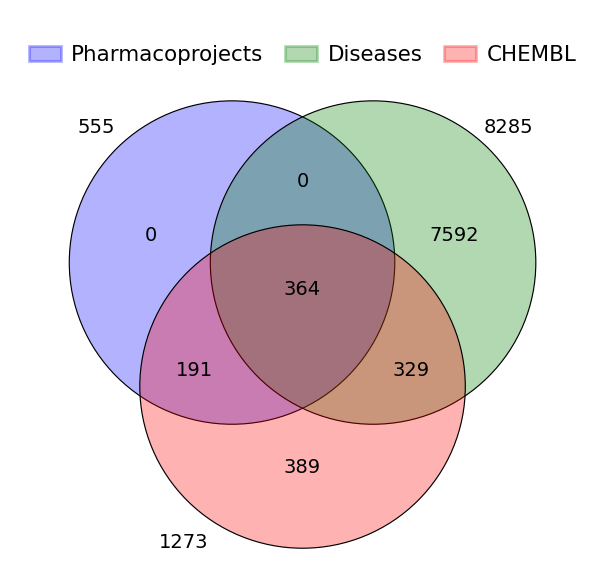

In [ ]:
from venny4py.venny4py import *

# dict of sets
sets = {
    "Pharmacoprojects": Pharmacoprojects,
    "Diseases": Diseases,
    "CHEMBL": CHEMBL,
}

plt.figure(figsize=(3, 3))
venny4py(sets=sets)
# plt.title("Gene Overlaps")
plt.show()

In [ ]:
target = session.spark.read.parquet(path_to_release_folder + "output/target/")
target = target.filter(f.col("biotype") == "protein_coding").cache()
target.count()

20130

In [ ]:
from pyspark.sql.functions import filter as array_filter, size, col

filtered_target = target.filter(
    size(
        array_filter(
            col("tractability"),
            lambda x: (x.id == "Druggable Family") & (x.value == True),
        )
    )
    > 0
)

In [93]:
filtered_target.count()

2292

In [ ]:
druggable_family = (
    filtered_target.select("id").distinct().rdd.map(lambda row: row[0]).collect()
)

In [ ]:
druggable_family = set(druggable_family)

In [ ]:
druggable_genes = (
    session.spark.read.option("header", "true")
    .option("sep", "\t")
    .csv(
        "/Users/yt4/Projects/gentropy/notebooks/gentropy_paper/data/druggable_genes.tsv"
    )
    .cache()
)
druggable_genes.show(1)

+---------------+-----------------+----------+-------+---------+--------+------+--------------------+------------------+-------------------+-------------+---------+
|ensembl_gene_id|druggability_tier|hgnc_names|chr_b37|start_b37| end_b37|strand|         description|no_of_gwas_regions|small_mol_druggable|bio_druggable|adme_gene|
+---------------+-----------------+----------+-------+---------+--------+------+--------------------+------------------+-------------------+-------------+---------+
|ENSG00000000938|           Tier 1|       FGR|      1| 27938575|27961788|    -1|feline Gardner-Ra...|                 0|                  Y|            N|        N|
+---------------+-----------------+----------+-------+---------+--------+------+--------------------+------------------+-------------------+-------------+---------+
only showing top 1 row



In [ ]:
druggable_genes = set(
    druggable_genes.select("ensembl_gene_id")
    .distinct()
    .rdd.map(lambda row: row[0])
    .collect()
)

<Figure size 600x600 with 0 Axes>

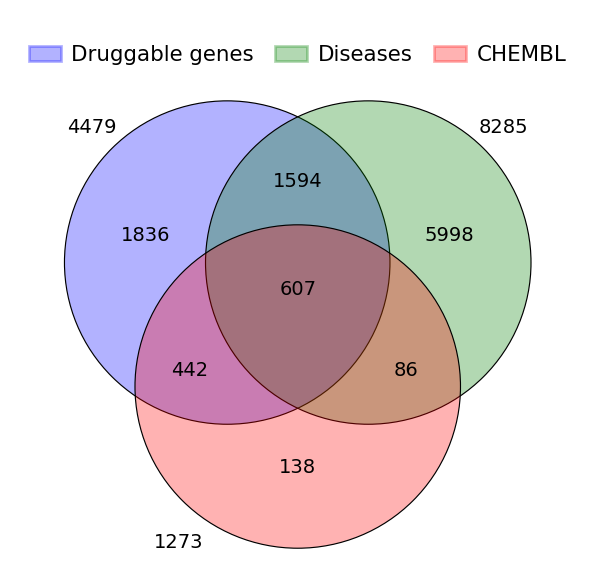

In [ ]:
from venny4py.venny4py import *

# dict of sets
sets = {
    "Druggable genes": druggable_genes,
    "Diseases": Diseases,
    "CHEMBL": CHEMBL,
}

plt.figure(figsize=(3, 3))
venny4py(sets=sets)
# plt.title("Gene Overlaps")
plt.show()

# Test run


In [10]:
l2g_full.show(1)

+--------------------+--------------------+---------------+-----------------+----------+----------+---+-----------+--------------------+--------------+----+------+---------------+----------+--------------+----+------------------+
|        studyLocusId|             studyId|         geneId|            score|eQTL_coloc|pQTL_coloc|VEP|distanceTSS|                 maf|     variantId|year|is_nfe|     diseaseIds|nfe_common|non_nfe_common|rare|           absBeta|
+--------------------+--------------------+---------------+-----------------+----------+----------+---+-----------+--------------------+--------------+----+------+---------------+----------+--------------+----+------------------+
|cd9dd38e1f85a069d...|FINNGEN_R12_H7_IR...|ENSG00000152954|0.344258189201355|         0|         0|  0|          1|0.029878971255673223|6_23867964_T_C|2024|     0|[MONDO_0004773]|         0|             1|   0|0.4207366138701276|
+--------------------+--------------------+---------------+-----------------+---

In [ ]:
evidence = chemblDrugEnrichment.to_disease_target_evidence(
    table_with_score=l2g_full.drop("diseaseIds"),
    score_column="score",
    datasource_id="l2g",
    study_locus=sl,
    study_index=si,
    min_score=0.1,
)

In [ ]:
enrich = chemblDrugEnrichment.drug_enrichemnt_from_evidence(
    evid=evidence,
    disease_index_orig=disease_index_orig,
    chembl_orig=chembl_evidence,
    indirect_assoc_score_thr=0.1,
    efo_ancestors_to_remove=["MONDO_0045024"],
)
enrich

,clinicalPhase,odds_ratio,p_value,ci_low,ci_high,no_evid-low_clinphase,no_evid-high_clinphase,yes_evid-low_clinphase,yes_evid-high_clinphase,total_indirect_assoc
0,2+,1.746148,1.154068e-06,1.375083,2.217346,6087,30548,76,666,151704
1,3+,2.060942,7.941172e-22,1.773924,2.394399,20294,16341,279,463,151704
2,4+,3.618578,3.534571e-49,3.093638,4.232591,32313,4322,500,242,151704


In [ ]:
enrich = chemblDrugEnrichment.drug_enrichemnt_from_evidence(
    evid=evidence,
    disease_index_orig=disease_index_orig,
    chembl_orig=chembl_no_train,
    indirect_assoc_score_thr=0.1,
    efo_ancestors_to_remove=["MONDO_0045024"],
)
enrich

25/08/21 12:21:04 WARN CacheManager: Asked to cache already cached data.        


,clinicalPhase,odds_ratio,p_value,ci_low,ci_high,no_evid-low_clinphase,no_evid-high_clinphase,yes_evid-low_clinphase,yes_evid-high_clinphase,total_indirect_assoc
0,2+,1.469538,1.803228e-03,1.145077,1.885936,6084,30380,71,521,151704
1,3+,1.654389,1.637471e-09,1.404170,1.949196,20271,16193,255,337,151704
2,4+,3.178015,4.093381e-31,2.656882,3.801364,32180,4284,416,176,151704


In [ ]:
enrich = chemblDrugEnrichment.drug_enrichemnt_from_evidence(
    evid=evidence,
    disease_index_orig=disease_index_orig,
    chembl_orig=pharmprj,
    indirect_assoc_score_thr=0.1,
    efo_ancestors_to_remove=["MONDO_0045024"],
)
enrich

25/08/21 12:21:27 WARN CacheManager: Asked to cache already cached data.        


,clinicalPhase,odds_ratio,p_value,ci_low,ci_high,no_evid-low_clinphase,no_evid-high_clinphase,yes_evid-low_clinphase,yes_evid-high_clinphase,total_indirect_assoc
0,2+,0.749570,0.127676,0.517925,1.084819,366,1878,39,150,151704
1,3+,1.236901,0.167977,0.918445,1.665777,1305,939,100,89,151704
2,4+,1.547011,0.008976,1.127747,2.122145,1686,558,125,64,151704


# Enrichment


In [ ]:
import pandas as pd

all_enrich = []

## Full


In [ ]:
evidence = chemblDrugEnrichment.to_disease_target_evidence(
    table_with_score=l2g_full.drop("diseaseIds"),
    score_column="score",
    datasource_id="l2g",
    study_locus=sl,
    study_index=si,
    min_score=0.1,
)

In [ ]:
enrich = chemblDrugEnrichment.drug_enrichemnt_from_evidence(
    evid=evidence,
    disease_index_orig=disease_index_orig,
    chembl_orig=chembl_evidence,
    indirect_assoc_score_thr=0.1,
    efo_ancestors_to_remove=["MONDO_0045024"],
)
enrich["datasource"] = "full_l2g"
enrich["drugsource"] = "full_chembl"
all_enrich.append(enrich)

In [ ]:
enrich = chemblDrugEnrichment.drug_enrichemnt_from_evidence(
    evid=evidence,
    disease_index_orig=disease_index_orig,
    chembl_orig=chembl_no_train,
    indirect_assoc_score_thr=0.1,
    efo_ancestors_to_remove=["MONDO_0045024"],
)
enrich["datasource"] = "full_l2g"
enrich["drugsource"] = "no_train_chembl"
all_enrich.append(enrich)

25/09/18 11:50:00 WARN CacheManager: Asked to cache already cached data.        


In [ ]:
enrich = chemblDrugEnrichment.drug_enrichemnt_from_evidence(
    evid=evidence,
    disease_index_orig=disease_index_orig,
    chembl_orig=pharmprj,
    indirect_assoc_score_thr=0.1,
    efo_ancestors_to_remove=["MONDO_0045024"],
)
enrich["datasource"] = "full_l2g"
enrich["drugsource"] = "Pharmaprojects"
all_enrich.append(enrich)

25/09/18 11:50:15 WARN CacheManager: Asked to cache already cached data.        


# Core


In [ ]:
core = session.spark.read.text(
    "/Users/yt4/Projects/gentropy/notebooks/gentropy_paper/data/genes_with_10_or_more_diseases.txt"
)

In [ ]:
core = core.withColumnRenamed("value", "geneId")

In [25]:
core.show(1)

+---------------+
|         geneId|
+---------------+
|ENSG00000147883|
+---------------+
only showing top 1 row



In [ ]:
evidence = chemblDrugEnrichment.to_disease_target_evidence(
    table_with_score=l2g_full.join(core, "geneId", "inner").drop("diseaseIds"),
    score_column="score",
    datasource_id="l2g",
    study_locus=sl,
    study_index=si,
    min_score=0.1,
)

In [ ]:
enrich = chemblDrugEnrichment.drug_enrichemnt_from_evidence(
    evid=evidence,
    disease_index_orig=disease_index_orig,
    chembl_orig=chembl_evidence,
    indirect_assoc_score_thr=0.1,
    efo_ancestors_to_remove=["MONDO_0045024"],
)
enrich["datasource"] = "core"
enrich["drugsource"] = "full_chembl"
all_enrich.append(enrich)

In [ ]:
enrich = chemblDrugEnrichment.drug_enrichemnt_from_evidence(
    evid=evidence,
    disease_index_orig=disease_index_orig,
    chembl_orig=chembl_no_train,
    indirect_assoc_score_thr=0.1,
    efo_ancestors_to_remove=["MONDO_0045024"],
)
enrich["datasource"] = "core"
enrich["drugsource"] = "no_train_chembl"
all_enrich.append(enrich)

25/09/18 11:50:58 WARN CacheManager: Asked to cache already cached data.        


In [ ]:
enrich = chemblDrugEnrichment.drug_enrichemnt_from_evidence(
    evid=evidence,
    disease_index_orig=disease_index_orig,
    chembl_orig=pharmprj,
    indirect_assoc_score_thr=0.1,
    efo_ancestors_to_remove=["MONDO_0045024"],
)
enrich["datasource"] = "core"
enrich["drugsource"] = "Pharmaprojects"
all_enrich.append(enrich)

25/09/18 11:51:14 WARN CacheManager: Asked to cache already cached data.        


# Not core


In [30]:
core.show(1)

+---------------+
|         geneId|
+---------------+
|ENSG00000147883|
+---------------+
only showing top 1 row



In [ ]:
evidence = chemblDrugEnrichment.to_disease_target_evidence(
    table_with_score=l2g_full.join(core, "geneId", "left_anti").drop("diseaseIds"),
    score_column="score",
    datasource_id="l2g",
    study_locus=sl,
    study_index=si,
    min_score=0.1,
)

In [ ]:
enrich = chemblDrugEnrichment.drug_enrichemnt_from_evidence(
    evid=evidence,
    disease_index_orig=disease_index_orig,
    chembl_orig=chembl_evidence,
    indirect_assoc_score_thr=0.1,
    efo_ancestors_to_remove=["MONDO_0045024"],
)
enrich["datasource"] = "peripheral"
enrich["drugsource"] = "full_chembl"
all_enrich.append(enrich)

In [ ]:
enrich = chemblDrugEnrichment.drug_enrichemnt_from_evidence(
    evid=evidence,
    disease_index_orig=disease_index_orig,
    chembl_orig=chembl_no_train,
    indirect_assoc_score_thr=0.1,
    efo_ancestors_to_remove=["MONDO_0045024"],
)
enrich["datasource"] = "peripheral"
enrich["drugsource"] = "no_train_chembl"
all_enrich.append(enrich)

25/09/18 11:51:53 WARN CacheManager: Asked to cache already cached data.        


In [ ]:
enrich = chemblDrugEnrichment.drug_enrichemnt_from_evidence(
    evid=evidence,
    disease_index_orig=disease_index_orig,
    chembl_orig=pharmprj,
    indirect_assoc_score_thr=0.1,
    efo_ancestors_to_remove=["MONDO_0045024"],
)
enrich["datasource"] = "peripheral"
enrich["drugsource"] = "Pharmaprojects"
all_enrich.append(enrich)

25/09/18 11:52:08 WARN CacheManager: Asked to cache already cached data.        


## Rare


In [ ]:
evidence = chemblDrugEnrichment.to_disease_target_evidence(
    table_with_score=l2g_full.drop("diseaseIds").filter(f.col("maf") < 0.01),
    score_column="score",
    datasource_id="l2g",
    study_locus=sl,
    study_index=si,
    min_score=0.1,
)

In [ ]:
enrich = chemblDrugEnrichment.drug_enrichemnt_from_evidence(
    evid=evidence,
    disease_index_orig=disease_index_orig,
    chembl_orig=chembl_evidence,
    indirect_assoc_score_thr=0.1,
    efo_ancestors_to_remove=["MONDO_0045024"],
)
enrich["datasource"] = "rare"
enrich["drugsource"] = "full_chembl"
all_enrich.append(enrich)

In [ ]:
enrich = chemblDrugEnrichment.drug_enrichemnt_from_evidence(
    evid=evidence,
    disease_index_orig=disease_index_orig,
    chembl_orig=chembl_no_train,
    indirect_assoc_score_thr=0.1,
    efo_ancestors_to_remove=["MONDO_0045024"],
)
enrich["datasource"] = "rare"
enrich["drugsource"] = "no_train_chembl"
all_enrich.append(enrich)

25/09/18 11:52:52 WARN CacheManager: Asked to cache already cached data.        


In [ ]:
enrich = chemblDrugEnrichment.drug_enrichemnt_from_evidence(
    evid=evidence,
    disease_index_orig=disease_index_orig,
    chembl_orig=pharmprj,
    indirect_assoc_score_thr=0.1,
    efo_ancestors_to_remove=["MONDO_0045024"],
)
enrich["datasource"] = "rare"
enrich["drugsource"] = "Pharmaprojects"
all_enrich.append(enrich)

25/09/18 11:53:09 WARN CacheManager: Asked to cache already cached data.        


## Common


In [ ]:
evidence = chemblDrugEnrichment.to_disease_target_evidence(
    table_with_score=l2g_full.drop("diseaseIds").filter(f.col("maf") >= 0.01),
    score_column="score",
    datasource_id="l2g",
    study_locus=sl,
    study_index=si,
    min_score=0.1,
)

In [ ]:
enrich = chemblDrugEnrichment.drug_enrichemnt_from_evidence(
    evid=evidence,
    disease_index_orig=disease_index_orig,
    chembl_orig=chembl_evidence,
    indirect_assoc_score_thr=0.1,
    efo_ancestors_to_remove=["MONDO_0045024"],
)
enrich["datasource"] = "common"
enrich["drugsource"] = "full_chembl"
all_enrich.append(enrich)

In [ ]:
enrich = chemblDrugEnrichment.drug_enrichemnt_from_evidence(
    evid=evidence,
    disease_index_orig=disease_index_orig,
    chembl_orig=chembl_no_train,
    indirect_assoc_score_thr=0.1,
    efo_ancestors_to_remove=["MONDO_0045024"],
)
enrich["datasource"] = "common"
enrich["drugsource"] = "no_train_chembl"
all_enrich.append(enrich)

25/09/18 11:53:53 WARN CacheManager: Asked to cache already cached data.        


In [ ]:
enrich = chemblDrugEnrichment.drug_enrichemnt_from_evidence(
    evid=evidence,
    disease_index_orig=disease_index_orig,
    chembl_orig=pharmprj,
    indirect_assoc_score_thr=0.1,
    efo_ancestors_to_remove=["MONDO_0045024"],
)
enrich["datasource"] = "common"
enrich["drugsource"] = "Pharmaprojects"
all_enrich.append(enrich)

25/09/18 11:54:10 WARN CacheManager: Asked to cache already cached data.        


# Big effect


In [ ]:
evidence = chemblDrugEnrichment.to_disease_target_evidence(
    table_with_score=l2g_full.drop("diseaseIds").filter(f.col("absBeta") >= 0.5),
    score_column="score",
    datasource_id="l2g",
    study_locus=sl,
    study_index=si,
    min_score=0.1,
)

In [ ]:
enrich = chemblDrugEnrichment.drug_enrichemnt_from_evidence(
    evid=evidence,
    disease_index_orig=disease_index_orig,
    chembl_orig=chembl_evidence,
    indirect_assoc_score_thr=0.1,
    efo_ancestors_to_remove=["MONDO_0045024"],
)
enrich["datasource"] = "Big effect"
enrich["drugsource"] = "full_chembl"
all_enrich.append(enrich)

In [ ]:
enrich = chemblDrugEnrichment.drug_enrichemnt_from_evidence(
    evid=evidence,
    disease_index_orig=disease_index_orig,
    chembl_orig=chembl_no_train,
    indirect_assoc_score_thr=0.1,
    efo_ancestors_to_remove=["MONDO_0045024"],
)
enrich["datasource"] = "Big effect"
enrich["drugsource"] = "no_train_chembl"
all_enrich.append(enrich)

25/09/18 11:54:49 WARN CacheManager: Asked to cache already cached data.        


In [ ]:
enrich = chemblDrugEnrichment.drug_enrichemnt_from_evidence(
    evid=evidence,
    disease_index_orig=disease_index_orig,
    chembl_orig=pharmprj,
    indirect_assoc_score_thr=0.1,
    efo_ancestors_to_remove=["MONDO_0045024"],
)
enrich["datasource"] = "Big effect"
enrich["drugsource"] = "Pharmaprojects"
all_enrich.append(enrich)

25/09/18 11:55:03 WARN CacheManager: Asked to cache already cached data.        


# Small effect


In [ ]:
evidence = chemblDrugEnrichment.to_disease_target_evidence(
    table_with_score=l2g_full.drop("diseaseIds").filter(f.col("absBeta") < 0.5),
    score_column="score",
    datasource_id="l2g",
    study_locus=sl,
    study_index=si,
    min_score=0.1,
)

In [ ]:
enrich = chemblDrugEnrichment.drug_enrichemnt_from_evidence(
    evid=evidence,
    disease_index_orig=disease_index_orig,
    chembl_orig=chembl_evidence,
    indirect_assoc_score_thr=0.1,
    efo_ancestors_to_remove=["MONDO_0045024"],
)
enrich["datasource"] = "Small effect"
enrich["drugsource"] = "full_chembl"
all_enrich.append(enrich)

In [ ]:
enrich = chemblDrugEnrichment.drug_enrichemnt_from_evidence(
    evid=evidence,
    disease_index_orig=disease_index_orig,
    chembl_orig=chembl_no_train,
    indirect_assoc_score_thr=0.1,
    efo_ancestors_to_remove=["MONDO_0045024"],
)
enrich["datasource"] = "Small effect"
enrich["drugsource"] = "no_train_chembl"
all_enrich.append(enrich)

25/09/18 11:55:44 WARN CacheManager: Asked to cache already cached data.        


In [ ]:
enrich = chemblDrugEnrichment.drug_enrichemnt_from_evidence(
    evid=evidence,
    disease_index_orig=disease_index_orig,
    chembl_orig=pharmprj,
    indirect_assoc_score_thr=0.1,
    efo_ancestors_to_remove=["MONDO_0045024"],
)
enrich["datasource"] = "Small effect"
enrich["drugsource"] = "Pharmaprojects"
all_enrich.append(enrich)

25/09/18 11:55:58 WARN CacheManager: Asked to cache already cached data.        


# Only PAV


In [ ]:
evidence = chemblDrugEnrichment.to_disease_target_evidence(
    table_with_score=l2g_full.drop("diseaseIds").filter(f.col("VEP") == 1),
    score_column="score",
    datasource_id="l2g",
    study_locus=sl,
    study_index=si,
    min_score=0.1,
)

In [ ]:
enrich = chemblDrugEnrichment.drug_enrichemnt_from_evidence(
    evid=evidence,
    disease_index_orig=disease_index_orig,
    chembl_orig=chembl_evidence,
    indirect_assoc_score_thr=0.1,
    efo_ancestors_to_remove=["MONDO_0045024"],
)
enrich["datasource"] = "PAV"
enrich["drugsource"] = "full_chembl"
all_enrich.append(enrich)

In [ ]:
enrich = chemblDrugEnrichment.drug_enrichemnt_from_evidence(
    evid=evidence,
    disease_index_orig=disease_index_orig,
    chembl_orig=chembl_no_train,
    indirect_assoc_score_thr=0.1,
    efo_ancestors_to_remove=["MONDO_0045024"],
)
enrich["datasource"] = "PAV"
enrich["drugsource"] = "no_train_chembl"
all_enrich.append(enrich)

25/09/18 11:56:38 WARN CacheManager: Asked to cache already cached data.        


In [ ]:
enrich = chemblDrugEnrichment.drug_enrichemnt_from_evidence(
    evid=evidence,
    disease_index_orig=disease_index_orig,
    chembl_orig=pharmprj,
    indirect_assoc_score_thr=0.1,
    efo_ancestors_to_remove=["MONDO_0045024"],
)
enrich["datasource"] = "PAV"
enrich["drugsource"] = "Pharmaprojects"
all_enrich.append(enrich)

25/09/18 11:56:53 WARN CacheManager: Asked to cache already cached data.        


# Replicated CSs


In [ ]:
repl_cs = session.spark.read.parquet(
    "gs://genetics-portal-dev-analysis/yt4/20250403_for_gentropy_paper/list_of_gwas_replicated_CSs.parquet"
)

In [ ]:
evidence = chemblDrugEnrichment.to_disease_target_evidence(
    table_with_score=l2g_full.drop("diseaseIds").join(repl_cs, "studyLocusId", "inner"),
    score_column="score",
    datasource_id="l2g",
    study_locus=sl,
    study_index=si,
    min_score=0.1,
)

In [ ]:
enrich = chemblDrugEnrichment.drug_enrichemnt_from_evidence(
    evid=evidence,
    disease_index_orig=disease_index_orig,
    chembl_orig=chembl_evidence,
    indirect_assoc_score_thr=0.1,
    efo_ancestors_to_remove=["MONDO_0045024"],
)
enrich["datasource"] = "Replicated CSs"
enrich["drugsource"] = "full_chembl"
all_enrich.append(enrich)

In [ ]:
enrich = chemblDrugEnrichment.drug_enrichemnt_from_evidence(
    evid=evidence,
    disease_index_orig=disease_index_orig,
    chembl_orig=chembl_no_train,
    indirect_assoc_score_thr=0.1,
    efo_ancestors_to_remove=["MONDO_0045024"],
)
enrich["datasource"] = "Replicated"
enrich["drugsource"] = "no_train_chembl"
all_enrich.append(enrich)

25/09/18 11:57:36 WARN CacheManager: Asked to cache already cached data.        


In [ ]:
enrich = chemblDrugEnrichment.drug_enrichemnt_from_evidence(
    evid=evidence,
    disease_index_orig=disease_index_orig,
    chembl_orig=pharmprj,
    indirect_assoc_score_thr=0.1,
    efo_ancestors_to_remove=["MONDO_0045024"],
)
enrich["datasource"] = "Replicated"
enrich["drugsource"] = "Pharmaprojects"
all_enrich.append(enrich)

25/09/18 11:57:51 WARN CacheManager: Asked to cache already cached data.        


# Not replicated CSs


In [ ]:
# repl_cs=session.spark.read.parquet("gs://genetics-portal-dev-analysis/yt4/20250403_for_gentropy_paper/list_of_gwas_replicated_CSs.parquet")

In [ ]:
evidence = chemblDrugEnrichment.to_disease_target_evidence(
    table_with_score=l2g_full.drop("diseaseIds").join(
        repl_cs, "studyLocusId", "left_anti"
    ),
    score_column="score",
    datasource_id="l2g",
    study_locus=sl,
    study_index=si,
    min_score=0.1,
)

In [ ]:
enrich = chemblDrugEnrichment.drug_enrichemnt_from_evidence(
    evid=evidence,
    disease_index_orig=disease_index_orig,
    chembl_orig=chembl_evidence,
    indirect_assoc_score_thr=0.1,
    efo_ancestors_to_remove=["MONDO_0045024"],
)
enrich["datasource"] = "Not replicated CSs"
enrich["drugsource"] = "full_chembl"
all_enrich.append(enrich)

In [ ]:
enrich = chemblDrugEnrichment.drug_enrichemnt_from_evidence(
    evid=evidence,
    disease_index_orig=disease_index_orig,
    chembl_orig=chembl_no_train,
    indirect_assoc_score_thr=0.1,
    efo_ancestors_to_remove=["MONDO_0045024"],
)
enrich["datasource"] = "Not replicated CSs"
enrich["drugsource"] = "no_train_chembl"
all_enrich.append(enrich)

25/09/18 11:58:33 WARN CacheManager: Asked to cache already cached data.        


In [ ]:
enrich = chemblDrugEnrichment.drug_enrichemnt_from_evidence(
    evid=evidence,
    disease_index_orig=disease_index_orig,
    chembl_orig=pharmprj,
    indirect_assoc_score_thr=0.1,
    efo_ancestors_to_remove=["MONDO_0045024"],
)
enrich["datasource"] = "Not replicated CSs"
enrich["drugsource"] = "Pharmaprojects"
all_enrich.append(enrich)

25/09/18 11:58:48 WARN CacheManager: Asked to cache already cached data.        


# OMIM


In [ ]:
combined_evidence = session.spark.read.csv(
    "./data/combined_evidence.csv", header=True, inferSchema=True
)
evidence = combined_evidence.filter(f.col("source") == "omim")

In [ ]:
enrich = chemblDrugEnrichment.drug_enrichemnt_from_evidence(
    evid=evidence,
    disease_index_orig=disease_index_orig,
    chembl_orig=chembl_evidence,
    indirect_assoc_score_thr=0,
    efo_ancestors_to_remove=["MONDO_0045024"],
)
enrich["datasource"] = "OMIM"
enrich["drugsource"] = "full_chembl"
all_enrich.append(enrich)

enrich = chemblDrugEnrichment.drug_enrichemnt_from_evidence(
    evid=evidence,
    disease_index_orig=disease_index_orig,
    chembl_orig=chembl_no_train,
    indirect_assoc_score_thr=0,
    efo_ancestors_to_remove=["OMIM"],
)
enrich["datasource"] = "Not replicated CSs"
enrich["drugsource"] = "no_train_chembl"
all_enrich.append(enrich)

enrich = chemblDrugEnrichment.drug_enrichemnt_from_evidence(
    evid=evidence,
    disease_index_orig=disease_index_orig,
    chembl_orig=pharmprj,
    indirect_assoc_score_thr=0,
    efo_ancestors_to_remove=["MONDO_0045024"],
)
enrich["datasource"] = "OMIM"
enrich["drugsource"] = "Pharmaprojects"
all_enrich.append(enrich)

25/09/18 11:59:36 WARN CacheManager: Asked to cache already cached data.        


# Gene-based


In [ ]:
combined_evidence = session.spark.read.csv(
    "./data/combined_evidence.csv", header=True, inferSchema=True
)
evidence = combined_evidence.filter(f.col("source") == "gene_burden")

In [ ]:
enrich = chemblDrugEnrichment.drug_enrichemnt_from_evidence(
    evid=evidence,
    disease_index_orig=disease_index_orig,
    chembl_orig=chembl_evidence,
    indirect_assoc_score_thr=0,
    efo_ancestors_to_remove=["MONDO_0045024"],
)
enrich["datasource"] = "Gene-based tests"
enrich["drugsource"] = "full_chembl"
all_enrich.append(enrich)

enrich = chemblDrugEnrichment.drug_enrichemnt_from_evidence(
    evid=evidence,
    disease_index_orig=disease_index_orig,
    chembl_orig=chembl_no_train,
    indirect_assoc_score_thr=0,
    efo_ancestors_to_remove=["OMIM"],
)
enrich["datasource"] = "Gene-based tests"
enrich["drugsource"] = "no_train_chembl"
all_enrich.append(enrich)

enrich = chemblDrugEnrichment.drug_enrichemnt_from_evidence(
    evid=evidence,
    disease_index_orig=disease_index_orig,
    chembl_orig=pharmprj,
    indirect_assoc_score_thr=0,
    efo_ancestors_to_remove=["MONDO_0045024"],
)
enrich["datasource"] = "Gene-based tests"
enrich["drugsource"] = "Pharmaprojects"
all_enrich.append(enrich)

25/09/18 12:05:32 WARN CacheManager: Asked to cache already cached data.        


# Orphanet


In [ ]:
combined_evidence = session.spark.read.csv(
    "./data/combined_evidence.csv", header=True, inferSchema=True
)
evidence = combined_evidence.filter(f.col("source") == "orphanet")

In [ ]:
enrich = chemblDrugEnrichment.drug_enrichemnt_from_evidence(
    evid=evidence,
    disease_index_orig=disease_index_orig,
    chembl_orig=chembl_evidence,
    indirect_assoc_score_thr=0,
    efo_ancestors_to_remove=["MONDO_0045024"],
)
enrich["datasource"] = "Orphanet"
enrich["drugsource"] = "full_chembl"
all_enrich.append(enrich)

enrich = chemblDrugEnrichment.drug_enrichemnt_from_evidence(
    evid=evidence,
    disease_index_orig=disease_index_orig,
    chembl_orig=chembl_no_train,
    indirect_assoc_score_thr=0,
    efo_ancestors_to_remove=["OMIM"],
)
enrich["datasource"] = "Orphanet"
enrich["drugsource"] = "no_train_chembl"
all_enrich.append(enrich)

enrich = chemblDrugEnrichment.drug_enrichemnt_from_evidence(
    evid=evidence,
    disease_index_orig=disease_index_orig,
    chembl_orig=pharmprj,
    indirect_assoc_score_thr=0,
    efo_ancestors_to_remove=["MONDO_0045024"],
)
enrich["datasource"] = "Orphanet"
enrich["drugsource"] = "Pharmaprojects"
all_enrich.append(enrich)

25/09/18 12:06:48 WARN CacheManager: Asked to cache already cached data.        


# Combine


In [ ]:
combined_enrich = pd.concat(all_enrich, ignore_index=True)
# combined_enrich

In [77]:
combined_enrich

,clinicalPhase,odds_ratio,p_value,ci_low,ci_high,no_evid-low_clinphase,no_evid-high_clinphase,yes_evid-low_clinphase,yes_evid-high_clinphase,total_indirect_assoc,datasource,drugsource
0,2+,1.746148,1.154068e-06,1.375083,2.217346,6087,30548,76,666,151704,full_l2g,full_chembl
1,3+,2.060942,7.941172e-22,1.773924,2.394399,20294,16341,279,463,151704,full_l2g,full_chembl
2,4+,3.618578,3.534571e-49,3.093638,4.232591,32313,4322,500,242,151704,full_l2g,full_chembl
3,2+,1.469538,1.803228e-03,1.145077,1.885936,6084,30380,71,521,151704,full_l2g,no_train_chembl
4,3+,1.654389,1.637471e-09,1.404170,1.949196,20271,16193,255,337,151704,full_l2g,no_train_chembl
...,...,...,...,...,...,...,...,...,...,...,...,...
112,3+,3.207947,2.648320e-28,2.595392,3.965075,46889,25149,136,234,61441,Orphanet,no_train_chembl
113,4+,6.695855,9.363504e-55,5.418031,8.275050,66035,6003,230,140,61441,Orphanet,no_train_chembl
114,2+,0.866112,6.364849e-01,0.479681,1.563853,391,1967,14,61,58653,Orphanet,Pharmaprojects
115,3+,2.356160,3.317037e-04,1.465234,3.788806,1377,981,28,47,58653,Orphanet,Pharmaprojects


In [78]:
combined_enrich.to_csv("./data/combined_enrich_all.csv", index=False)

# Plotting


In [ ]:
combined_enrich = pd.read_csv("./data/combined_enrich_all.csv")

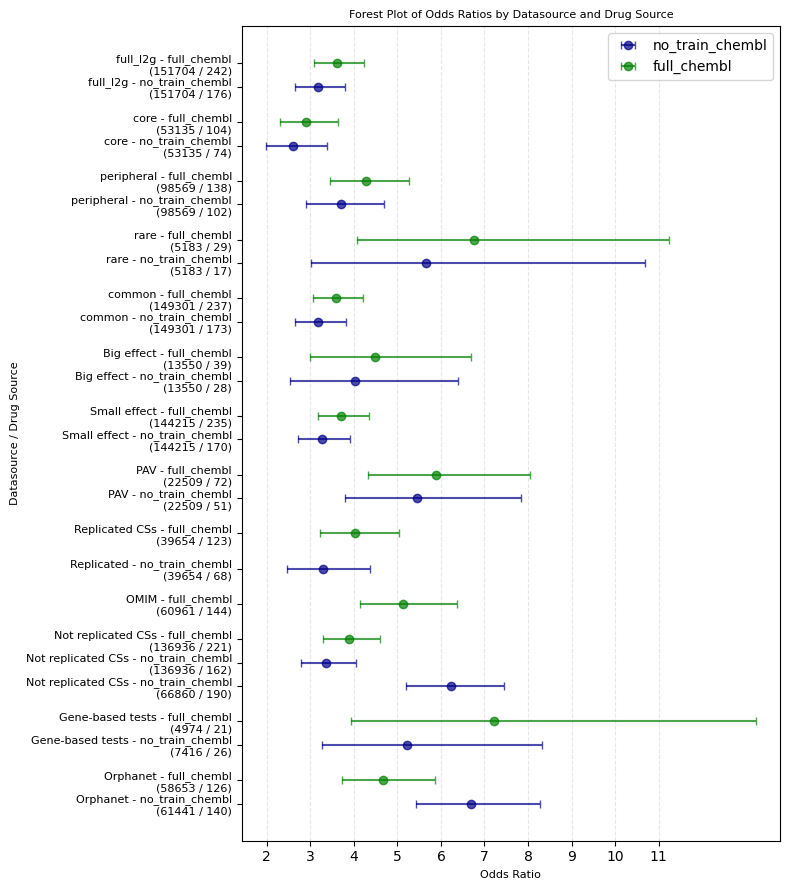

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Filter and sort the DataFrame
combined_enrich_4 = combined_enrich[combined_enrich["clinicalPhase"] == "4+"]
combined_enrich_4 = combined_enrich_4[
    combined_enrich_4["drugsource"] != "Pharmaprojects"
]
combined_enrich_4 = combined_enrich_4.iloc[::-1]
# combined_enrich_4 = combined_enrich_4.sort_values(by=["datasource", "drugsource", "odds_ratio"], ascending=[True, True, True])

# Get unique datasources and drugsources
unique_datasources = combined_enrich_4["datasource"].unique()
unique_drugsources = combined_enrich_4["drugsource"].unique()
colors = ["darkblue", "green", "black"]  # Two different colors for the two drugsources

# Create the plot
plt.figure(figsize=(8, 9))

# Create y-positions for each datasource group
y_positions = []
y_labels = []
y_pos = 0

for datasource in unique_datasources:
    datasource_data = combined_enrich_4[combined_enrich_4["datasource"] == datasource]

    for i, drugsource in enumerate(unique_drugsources):
        drugsource_data = datasource_data[datasource_data["drugsource"] == drugsource]

        if not drugsource_data.empty:
            for _, row in drugsource_data.iterrows():
                odds_ratio = row["odds_ratio"]
                ci_low = row["ci_low"]
                ci_high = row["ci_high"]

                # Plot the point with error bars
                plt.errorbar(
                    odds_ratio,
                    y_pos,
                    xerr=[[odds_ratio - ci_low], [ci_high - odds_ratio]],
                    fmt="o",
                    color=colors[i],
                    ecolor=colors[i],
                    capsize=3,
                    alpha=0.7,
                    label=drugsource if datasource == unique_datasources[0] else "",
                )

                # Create label
                label = f"{datasource} - {drugsource}\n({row['total_indirect_assoc']} / {row['yes_evid-high_clinphase']})"
                y_labels.append(label)
                y_positions.append(y_pos)
                y_pos += 1

    # Add some spacing between datasource groups
    y_pos += 0.5

# Customize the plot
# plt.axvline(x=1, color='black', linestyle='--', alpha=0.5, label="Null Effect (OR=1)")
plt.xlabel("Odds Ratio", fontsize=8)
plt.ylabel("Datasource / Drug Source", fontsize=8)
plt.title("Forest Plot of Odds Ratios by Datasource and Drug Source", fontsize=8)

# Set y-tick labels
plt.yticks(y_positions, y_labels, fontsize=8)
plt.legend(loc="upper right")
plt.grid(axis="x", linestyle="--", alpha=0.3)
plt.xticks([2, 3, 4, 5, 6, 7, 8, 9, 10, 11])

# Adjust layout and show
plt.tight_layout()
plt.show()

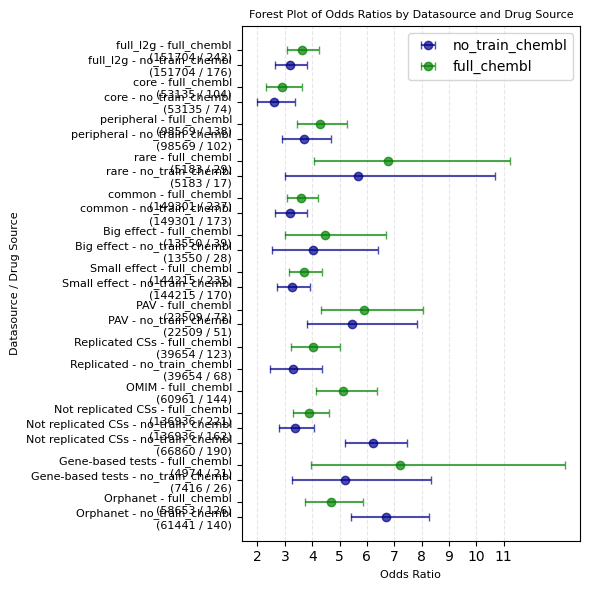

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Filter and sort the DataFrame
combined_enrich_4 = combined_enrich[combined_enrich["clinicalPhase"] == "4+"]
combined_enrich_4 = combined_enrich_4[
    combined_enrich_4["drugsource"] != "Pharmaprojects"
]
combined_enrich_4 = combined_enrich_4.iloc[::-1]
# combined_enrich_4 = combined_enrich_4.sort_values(by=["datasource", "drugsource", "odds_ratio"], ascending=[True, True, True])

# Get unique datasources and drugsources
unique_datasources = combined_enrich_4["datasource"].unique()
unique_drugsources = combined_enrich_4["drugsource"].unique()
colors = ["darkblue", "green"]  # Two different colors for the two drugsources

# Create the plot
plt.figure(figsize=(6, 6))

# Create y-positions for each datasource group
y_positions = []
y_labels = []
y_pos = 0

for datasource in unique_datasources:
    datasource_data = combined_enrich_4[combined_enrich_4["datasource"] == datasource]

    for i, drugsource in enumerate(unique_drugsources):
        drugsource_data = datasource_data[datasource_data["drugsource"] == drugsource]

        if not drugsource_data.empty:
            for _, row in drugsource_data.iterrows():
                odds_ratio = row["odds_ratio"]
                ci_low = row["ci_low"]
                ci_high = row["ci_high"]

                # Plot the point with error bars
                plt.errorbar(
                    odds_ratio,
                    y_pos,
                    xerr=[[odds_ratio - ci_low], [ci_high - odds_ratio]],
                    fmt="o",
                    color=colors[i],
                    ecolor=colors[i],
                    capsize=3,
                    alpha=0.7,
                    label=drugsource if datasource == unique_datasources[0] else "",
                )

                # Create label
                label = f"{datasource} - {drugsource}\n({row['total_indirect_assoc']} / {row['yes_evid-high_clinphase']})"
                y_labels.append(label)
                y_positions.append(y_pos)
                y_pos += 1

    # Add some spacing between datasource groups
    y_pos += 0.5

# Customize the plot
# plt.axvline(x=1, color='black', linestyle='--', alpha=0.5, label="Null Effect (OR=1)")
plt.xlabel("Odds Ratio", fontsize=8)
plt.ylabel("Datasource / Drug Source", fontsize=8)
plt.title("Forest Plot of Odds Ratios by Datasource and Drug Source", fontsize=8)

# Set y-tick labels
plt.yticks(y_positions, y_labels, fontsize=8)
plt.legend(loc="upper right")
plt.grid(axis="x", linestyle="--", alpha=0.3)
plt.xticks([2, 3, 4, 5, 6, 7, 8, 9, 10, 11])

# Adjust layout and show
plt.tight_layout()
plt.show()

In [ ]:
# Filter and sort the DataFrame
combined_enrich_4 = combined_enrich[combined_enrich["clinicalPhase"] == "4+"]
combined_enrich_4 = combined_enrich_4[
    combined_enrich_4["drugsource"] != "Pharmaprojects"
]
combined_enrich_4 = combined_enrich_4[
    combined_enrich_4["drugsource"] != "no_train_chembl"
]
combined_enrich_4 = combined_enrich_4.iloc[::-1]
# combined_enrich_4 = combined_enrich_4.sort_values(by=["datasource", "drugsource", "odds_ratio"], ascending=[True, True, True])

In [ ]:
# Replace multiple values
combined_enrich_4["datasource"] = combined_enrich_4["datasource"].replace(
    {
        "PAV": "Genes with PAV",
        "common": "Common Variants",
        "rare": "Rare Variants",
        "peripheral": "Low pleiotropy (PS<10)",
        "core": "High pleiotropy (10+)",
        "full_l2g": "All genes",
    }
)
combined_enrich_4 = combined_enrich_4[
    combined_enrich_4["datasource"] != "Not replicated CSs"
]
combined_enrich_4 = combined_enrich_4[
    combined_enrich_4["datasource"] != "Replicated CSs"
]

In [103]:
combined_enrich_4

,clinicalPhase,odds_ratio,p_value,ci_low,ci_high,no_evid-low_clinphase,no_evid-high_clinphase,yes_evid-low_clinphase,yes_evid-high_clinphase,total_indirect_assoc,datasource,drugsource
110,4+,4.676656,1.306846e-34,3.732320,5.859924,32615,4438,198,126,58653,Orphanet,full_chembl
101,4+,7.218138,2.586892e-09,3.939022,13.227017,32792,4543,21,21,4974,Gene-based tests,full_chembl
92,4+,5.131773,1.406205e-42,4.139005,6.362663,32606,4420,207,144,60961,OMIM,full_chembl
65,4+,5.893444,1.046782e-24,4.312868,8.053267,32724,4492,89,72,22509,Genes with PAV,full_chembl
56,4+,3.711583,2.904074e-49,3.164037,4.353882,32340,4329,473,235,144215,Small effect,full_chembl
47,4+,4.480400,1.838381e-11,3.001627,6.687701,32750,4525,63,39,13550,Big effect,full_chembl
38,4+,3.598166,6.676348e-48,3.071709,4.214851,32321,4327,492,237,149301,Common Variants,full_chembl
29,4+,6.762300,7.290363e-12,4.071700,11.230863,32782,4535,31,29,5183,Rare Variants,full_chembl
20,4+,4.267516,1.364300e-34,3.452101,5.275539,32575,4426,238,138,98569,Low pleiotropy (PS<10),full_chembl
11,4+,2.897087,9.038398e-17,2.303435,3.643737,32551,4460,262,104,53135,High pleiotropy (10+),full_chembl


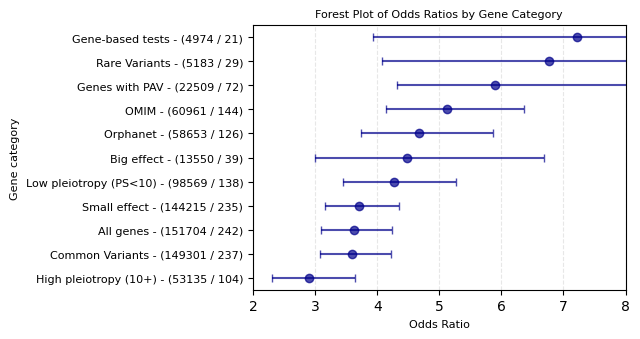

25/09/18 17:25:25 WARN HeartbeatReceiver: Removing executor driver with no recent heartbeats: 482919 ms exceeds timeout 120000 ms
25/09/18 17:25:26 WARN SparkContext: Killing executors is not supported by current scheduler.
25/09/18 17:25:27 WARN Executor: Issue communicating with driver in heartbeater
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:56)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:310)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEndpointRef.askSync(RpcEndpointRef.scala:101)
	at org.apache.spark.rpc.RpcEndpointRef.askSync(RpcEndpointRef.scala:85)
	at org.apache.spark.storage.BlockManagerMaster.registerBlockManager(BlockManagerMaster.scala:80)
	at org.apache.spark.storage.BlockManager.reregister(BlockManager.scala:642)
	at org.apache.spark.executor.Executor.reportHeartBeat(Executor.scala:1223)
	at o

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


# Get unique datasources and drugsources
combined_enrich_4 = combined_enrich_4.sort_values(by="odds_ratio", ascending=True)
unique_datasources = combined_enrich_4["datasource"].unique()
unique_drugsources = combined_enrich_4["drugsource"].unique()
colors = ["darkblue", "green"]  # Two different colors for the two drugsources

# Create the plot
plt.figure(figsize=(6.5, 3.5))

# Create y-positions for each datasource group
y_positions = []
y_labels = []
y_pos = 0

for datasource in unique_datasources:
    datasource_data = combined_enrich_4[combined_enrich_4["datasource"] == datasource]

    for i, drugsource in enumerate(unique_drugsources):
        drugsource_data = datasource_data[datasource_data["drugsource"] == drugsource]

        if not drugsource_data.empty:
            for _, row in drugsource_data.iterrows():
                odds_ratio = row["odds_ratio"]
                ci_low = row["ci_low"]
                ci_high = row["ci_high"]

                # Plot the point with error bars
                plt.errorbar(
                    odds_ratio,
                    y_pos,
                    xerr=[[odds_ratio - ci_low], [ci_high - odds_ratio]],
                    fmt="o",
                    color=colors[i],
                    ecolor=colors[i],
                    capsize=3,
                    alpha=0.7,
                    label=drugsource if datasource == unique_datasources[0] else "",
                )

                # Create label
                label = f"{datasource} - ({row['total_indirect_assoc']} / {row['yes_evid-high_clinphase']})"
                y_labels.append(label)
                y_positions.append(y_pos)
                y_pos += 1

    # Add some spacing between datasource groups
    y_pos += 0.5

# Customize the plot
# plt.axvline(x=1, color='black', linestyle='--', alpha=0.5, label="Null Effect (OR=1)")
plt.xlabel("Odds Ratio", fontsize=8)
plt.ylabel("Gene category", fontsize=8)
plt.title("Forest Plot of Odds Ratios by Gene Category", fontsize=8)

# Set y-tick labels
plt.yticks(y_positions, y_labels, fontsize=8)
# plt.legend(loc='upper right')
plt.grid(axis="x", linestyle="--", alpha=0.3)
plt.xlim(2, 8)
plt.xticks([2, 3, 4, 5, 6, 7, 8])

# Adjust layout and show
plt.tight_layout()
plt.show()

In [96]:
combined_enrich_4

,clinicalPhase,odds_ratio,p_value,ci_low,ci_high,no_evid-low_clinphase,no_evid-high_clinphase,yes_evid-low_clinphase,yes_evid-high_clinphase,total_indirect_assoc,datasource,drugsource
2,4+,3.618578,3.534571e-49,3.093638,4.232591,32313,4322,500,242,151704,All genes,full_chembl
11,4+,2.897087,9.038398e-17,2.303435,3.643737,32551,4460,262,104,53135,High pleiotropy (10+),full_chembl
20,4+,4.267516,1.364300e-34,3.452101,5.275539,32575,4426,238,138,98569,Low pleiotropy (0-9),full_chembl
29,4+,6.762300,7.290363e-12,4.071700,11.230863,32782,4535,31,29,5183,Rare Variants,full_chembl
38,4+,3.598166,6.676348e-48,3.071709,4.214851,32321,4327,492,237,149301,Common Variants,full_chembl
47,4+,4.480400,1.838381e-11,3.001627,6.687701,32750,4525,63,39,13550,Big effect,full_chembl
56,4+,3.711583,2.904074e-49,3.164037,4.353882,32340,4329,473,235,144215,Small effect,full_chembl
65,4+,5.893444,1.046782e-24,4.312868,8.053267,32724,4492,89,72,22509,Genes with PAV,full_chembl
92,4+,5.131773,1.406205e-42,4.139005,6.362663,32606,4420,207,144,60961,OMIM,full_chembl
101,4+,7.218138,2.586892e-09,3.939022,13.227017,32792,4543,21,21,4974,Gene-based tests,full_chembl
